# Approfondimento su MongoDB — Manuel Testoni (219155)

> Repository: [github.com/ManuelTestoni/BigData](https://github.com/ManuelTestoni/BigData/Fitness_Exercise_Analysis
> )

## Contesto dell'analisi

Per l'approfondimento sui sistemi NoSQL ho scelto MongoDB, un database citato a lezione che si basa su dati semi strutturati. Il modello utilizzato da MongoDB rinuncia allo schema rigido, tipico degli RDBMS, in favore di docuemnti BSON annidati. In questo approfondimento andremo a capire quando questo modello conviene davvero, quali garanzie offre e a cosa rinuncia, dato che sappiamo dal CAP theorem che non si possono garantire tutti e tre i principi.


Come caso di studio uso un dataset Kaggle di programmi di allenamento composto 605.033 righe, una per esercizio. Il CSV è completamente denormalizzato e quindi ogni riga ripete tutti i metadati del programma (titolo, descrizione, livello, obiettivo, equipment...). I dati hanno una gerarchia naturale a 4 livelli: programma → settimana → giorno → esercizio, questo mi ha spinto a voler utilizzare un architettura NoSQL documentale.

Per la simulazione d'analisi ho virtualizzato 3 nodi MongoDB su container docker.

Le research question che mi sono posto sono:

- **RQ1 — Modellazione:** conviene rimodellare il dataset piatto in documenti annidati o possiamo lasciarli standard? Confronto spazio e accesso.
- **RQ2 — Aggregation framework:** che analisi si possono fare direttamente nel database con le pipeline di aggregazione, senza estrarre i dati?
- **RQ3 — Indici:** Che impatto possono avere gli indici supportati da MongoDB? Anche in questo assignment profileremo la query.
- **RQ4 — Teorema CAP:** come si comporta il replica set sotto partizione? Vediamo scenari in cui i nodi falliscono.


## 1. Setup — Librerie e connessione al cluster

Le dipendenze sono elencate in `requirements.txt`: `pymongo`, `pandas`, `python-dotenv`, `tqdm`, `matplotlib`, `seaborn`.

> **Replica set locale**: il notebook si connette a un replica set `rs0` a 3 nodi che gira in Docker
> (`docker compose up -d` + inizializzazione con `rs-init.js`, vedi README). La connection string in `.env`
> elenca tutti e tre i membri: il driver scopre da solo la topologia e indirizza le operazioni al nodo giusto.
>
> `mongodb://localhost:27017,localhost:27018,localhost:27019/?replicaSet=rs0`


In [1]:
import warnings; warnings.filterwarnings("ignore")
import os, ast, time, subprocess
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from dotenv import load_dotenv
from pymongo import MongoClient, ASCENDING, WriteConcern, ReadPreference

sns.set_theme(style="whitegrid")
load_dotenv()

MONGO_URI = os.getenv("MONGO_URI")
MONGO_DB  = os.getenv("MONGO_DB", "fitness_db")

client = MongoClient(MONGO_URI)
db = client[MONGO_DB]

print("Ping:", client.admin.command("ping")["ok"])
print("URI :", MONGO_URI)
print("DB  :", MONGO_DB)

Ping: 1.0
URI : mongodb://localhost:27017,localhost:27018,localhost:27019/?replicaSet=rs0
DB  : fitness_db


In [2]:
status = client.admin.command("replSetGetStatus")
print(f"Replica set: {status['set']}")
pd.DataFrame([{"membro": m["name"], "stato": m["stateStr"],
               "health": int(m["health"]), "uptime (s)": m["uptime"]}
              for m in status["members"]])

Replica set: rs0


,membro,stato,health,uptime (s)
0,localhost:27017,PRIMARY,1,217
1,localhost:27018,SECONDARY,1,136
2,localhost:27019,SECONDARY,1,211


Vediamo che sono stati correttamente creati 3 container docker (ovviamente in locale) in ascolto su porte diverse. Notiamo anche che uno è stato eletto primary (e sarà il nodo che riceverà tutte le scritture) e due sono di default diventati secondary (che replicheranno in modo asincrono a meno che le richieste non siano specifiche su nodi secondary).

## 2. Ingestione dei dati

Importo il CSV piatto nella collection `workouts`, una riga per esercizio. Due accortezze in fase di import:

1. le colonne `level` e `goal` contengono **liste serializzate come stringhe** (es. `"['Beginner', 'Novice']"`): le riconverto in veri array Python, che BSON memorizza come array nativi — fondamentale per poterci fare `$unwind` nella RQ2;
2. `created`/`last_edit` diventano `datetime` e i pochi valori mancanti diventano `None`, cioè BSON `null`.

> **Write concern**: su un replica set il write concern di default è w: "majority" — ogni insert_many viene confermato solo quando la maggioranza dei nodi (2 su 3) ha applicato la scrittura. Ne misurerò il costo nella RQ4.


In [ ]:
CSV = "archive/programs_detailed_boostcamp_kaggle.csv"
df = pd.read_csv(CSV)
print(f"Righe nel CSV: {len(df):,} — colonne: {len(df.columns)}")

# 'level' e 'goal': liste serializzate -> veri array
for col in ("level", "goal"):
    mapping = {s: ast.literal_eval(s) for s in df[col].unique()}
    df[col] = df[col].map(mapping)

# date trattiamo come datatime. 
for col in ("created", "last_edit"):
    df[col] = pd.to_datetime(df[col])

# NaN/NaT trattiamo come None così che diventino Null nel DB. 
for col in df.columns:
    if col not in ("level", "goal") and df[col].isna().any():
        df[col] = df[col].astype(object).where(df[col].notna(), None)

workouts = db["workouts"]
workouts.drop()          

#Importiamo in batch di 5000 docuemnti alla volta.
records = df.to_dict(orient="records")
BATCH = 5000
for i in tqdm(range(0, len(records), BATCH), mininterval=5):
    workouts.insert_many(records[i:i + BATCH])

print(f"Documenti importati in 'workouts': {workouts.count_documents({}):,}")

Righe nel CSV: 605,033 — colonne: 16



  0%|          | 0/122 [00:00<?, ?it/s]


 55%|█████▍    | 67/122 [00:05<00:04, 13.39it/s]


100%|██████████| 122/122 [00:09<00:00, 13.18it/s]

Documenti importati in 'workouts': 605,033


I 605.033 documenti sono entrati a batch di 5.000 tramite `insert_many`. Ogni batch è stato scritto sul primary e confermato dalla maggioranza del replica set (write concern `majority`): la durabilità è garantita anche se un nodo cade subito dopo l'import. La collection `workouts` riproduce fedelmente il CSV. 


## 3. RQ1 — Modellazione: dal CSV piatto ai documenti annidati

Nel CSV ogni esercizio ripete tutti i metadati del suo programma: per un programma con 230 esercizi, titolo, descrizione, livello e obiettivo sono duplicati 230 volte. In un database relazionale normalizzerei in 4 tabelle (programs, weeks, days, exercises) e ricostruirei il programma con 3 join. MongoDB offre una terza via, l'embedding: un documento per programma, con la gerarchia settimane → giorni → esercizi annidata dentro.

Avrei potuto scegliere, invece che l'embedding, il referencing, ma dato che quando si parla di piani di allenamento, il pattern di accesso è per l'intero piano e non per i sotto oggetti, ha più senso proseguire con l'embedding. 

Duneque costruisco la collection "programs", che aggrega giorni → settimana → programma che finirà in "$out".

In [4]:
meta_first = {campo: {"$first": f"${campo}"}
              for campo in ("description", "level", "goal", "equipment",
                            "program_length", "time_per_workout", "created", "last_edit")}

pipeline = [
    # (programma, settimana, giorno) -> array di esercizi
    {"$group": {
        "_id": {"title": "$title", "week": {"$toInt": "$week"}, "day": {"$toInt": "$day"}},
        "exercises": {"$push": {"name": "$exercise_name", "sets": "$sets",
                                "reps": "$reps", "intensity": "$intensity"}},
        **meta_first}},
    # (programma, settimana) -> array di giorni
    {"$group": {
        "_id": {"title": "$_id.title", "week": "$_id.week"},
        "days": {"$push": {"day": "$_id.day", "exercises": "$exercises"}},
        **{k: {"$first": f"${k}"} for k in meta_first}}},
    # programma -> array di settimane (l'_id del documento è il titolo)
    {"$group": {
        "_id": "$_id.title",
        "weeks": {"$push": {"week": "$_id.week", "days": "$days"}},
        **{k: {"$first": f"${k}"} for k in meta_first}}},
    # dato che $push non garantisce l'ordine ordino io sulla settimana e sul giorno
    {"$addFields": {"weeks": {"$sortArray": {
        "input": {"$map": {"input": "$weeks", "as": "w",
                           "in": {"week": "$$w.week",
                                  "days": {"$sortArray": {"input": "$$w.days",
                                                          "sortBy": {"day": 1}}}}}},
        "sortBy": {"week": 1}}}}},
    {"$out": "programs"},
]

t0 = time.perf_counter()
db.workouts.aggregate(pipeline, allowDiskUse=True)
programs = db["programs"]
print(f"Pipeline completata in {time.perf_counter() - t0:.1f}s")
print(f"Programmi in 'programs': {programs.count_documents({}):,} "
      f"(da {db.workouts.count_documents({}):,} righe piatte)")

Pipeline completata in 4.4s


Programmi in 'programs': 2,598 (da 605,033 righe piatte)


Notiamo come dai 605.033 documenti di partenza sia riuscito a collassarli in 2.598 documenti unici (dato che il titolo fa da chiave naturale "_id").

Inoltre ho impostato allowDiskUse = True in quanto data la mole di documenti questi superano il limite default di MongoDB di 100MB di RAM, in questo modo permettiamo lo spilling su disco.

In [5]:
doc = programs.find_one({"_id": "Weightlifting Mobility program"})
print("Programma :", doc["_id"])
print("Equipment :", doc["equipment"])
print("Livelli   :", doc["level"])
print("Settimane :", len(doc["weeks"]))
w1 = doc["weeks"][0]
d1 = w1["days"][0]
print(f"Settimana {w1['week']} -> giorni {[d['day'] for d in w1['days']]}")
print(f"Giorno {d1['day']} -> {len(d1['exercises'])} esercizi, i primi 3:")
for ex in d1["exercises"][:3]:
    print("   -", ex)

Programma : Weightlifting Mobility program
Equipment : Garage Gym
Livelli   : ['Beginner', 'Novice', 'Intermediate', 'Advanced']
Settimane : 7
Settimana 1 -> giorni [1, 2, 3, 4, 5]
Giorno 1 -> 16 esercizi, i primi 3:
   - {'name': 'Knee-to-wall ankle dorsiflexion test', 'sets': 3.0, 'reps': -180.0, 'intensity': 6.0}
   - {'name': 'Banded ankle distractions', 'sets': 3.0, 'reps': -18.0, 'intensity': 6.0}
   - {'name': 'Slant board calf stretch', 'sets': 3.0, 'reps': -18.0, 'intensity': 6.0}


Ogni singolo docuemnto della nostra collezione è costituito come segue:
- Programma (id univoco che fa da chiave)
- Equipaggiamento
- Livello di esperienza
- Durata in settimane
- Giorni per settimana
- Esercizi per giorno (ognuno con i suoi campi)



In [6]:
def coll_stats(name):
    s = db.command("collStats", name)
    return {"collection": name,
            "n. documenti": s["count"],
            "dati (MB)": round(s["size"] / 1024**2, 1),
            "doc medio (KB)": round(s["avgObjSize"] / 1024, 2),
            "storage su disco (MB)": round(s["storageSize"] / 1024**2, 1)}

pd.DataFrame([coll_stats("workouts"), coll_stats("programs")]).set_index("collection")

,n. documenti,dati (MB),doc medio (KB),storage su disco (MB)
collection,,,,
workouts,605033,413.8,0.70,45.3
programs,2598,54.4,21.43,7.4


In [7]:
TITLE = "Weightlifting Mobility program"
N = 10

t0 = time.perf_counter()
for _ in range(N):
    rows = list(db.workouts.find({"title": TITLE}))
t_flat = (time.perf_counter() - t0) / N * 1000

t0 = time.perf_counter()
for _ in range(N):
    p = programs.find_one({"_id": TITLE})
t_nested = (time.perf_counter() - t0) / N * 1000

print("Pattern di accesso: 'recupera l'intero programma X'")
print(f"  flat  : {len(rows):>3} documenti da leggere e riassemblare — {t_flat:7.1f} ms/query (collection scan: nessun indice su 'title')")
print(f"  nested:   1 documento già completo               — {t_nested:7.2f} ms/query (lookup sull'_id, indicizzato di default)")

Pattern di accesso: 'recupera l'intero programma X'
  flat  : 325 documenti da leggere e riassemblare —   163.7 ms/query (collection scan: nessun indice su 'title')
  nested:   1 documento già completo               —    1.19 ms/query (lookup sull'_id, indicizzato di default)


Il confronto quantifica i due vantaggi dell'embedding su questo dataset:

1. **Storage**: Ho ridotto notevolmente i dati memorizzati, collassando documenti aumentando la dimensione del documento singolo (seppur rimanendo molto sotto la soglia die 16 MB massima prevista per singolo documento -> Vincolo strutturale). 
2. **Pattern di accesso**: l'intero programma si recupera con una lettura di un singolo documento (~1,2 ms, servita dall'indice di default su `_id`); nella versione piatta servono 325 documenti da filtrare. Senza indice questo comporta una scansione completa dei 605k documenti, ~165 ms che poi è da riassemblare lato applicazione. L'accesso al documento è inoltre atomico, ovvero una modifica al programma intero non richiede transazioni multi-documento in quanto sono stati raggruppati.

**Quando invece conviene il referencing?** Se i sotto-oggetti fossero acceduti indipendentemente dal padre (es. "tutti i giorni di allenamento di oggi, di qualunque programma") allora potrei valutare uno schema referencing. È il classico trade-off del modello documentale: si modella in base a come si legge, non in base alla struttura "pura" dei dati.

**Risposta a RQ1**: sì, per questo dataset, con questo pattern di accesso, il modello annidato è superiore su storage, semplicità e atomicità.

## 4. RQ2 — Aggregation framework: analytics direttamente sui documenti

Inizio dalla domanda più naturale: *quali sono gli esercizi più usati nei programmi?*

Per rispondere a questa domanda, dal momento in cui ho compattato i documenti, è necessario utilizzare la soluzione proposta da MongoDB di Aggregation Framework. Questa tecnica permette di unire la clausola "GROUP BY" (alla quale siamo già abituati) a funzioni analitiche quali: `$unwind`, `$group`, `$sort`, `$facet`, ...

Questo ha permesso di rispondere alla domanda sopra andando a sfruttare al clausola $unwind, già vista anche in Neo4j che permette di srotolare un array.


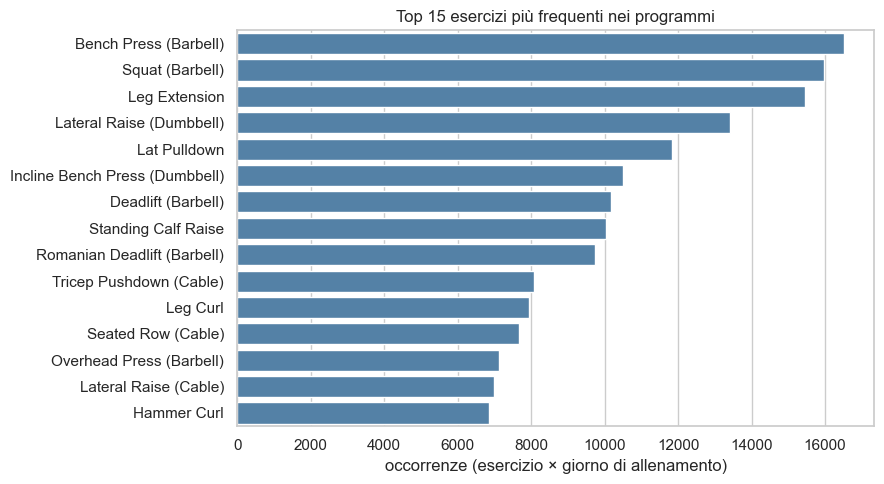

In [8]:
top = list(programs.aggregate([
    {"$unwind": "$weeks"},
    {"$unwind": "$weeks.days"},
    {"$unwind": "$weeks.days.exercises"},
    {"$group": {"_id": "$weeks.days.exercises.name", "frequenza": {"$sum": 1}}},
    {"$sort": {"frequenza": -1}},
    {"$limit": 15},
]))
top_df = pd.DataFrame(top).rename(columns={"_id": "esercizio"})

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=top_df, y="esercizio", x="frequenza", color="steelblue", ax=ax)
ax.set_title("Top 15 esercizi più frequenti nei programmi")
ax.set_xlabel("occorrenze (esercizio × giorno di allenamento)")
ax.set_ylabel("")
plt.tight_layout(); plt.show()

La successione dei tre $unwind, ha srotolato i documenti collassati, permettendo di tornare alle 605 mila righe di partenza. Infine la clausola $group ha permesso di contarle per nome.

Vediamo che i primi esercizi sono esercizi multi articolari (Panca piana, Squat o Stacco da terra), chiamati anche "Fondamentali" in quanto coinvolgono molti muscoli all'interno del corpo in un solo movimento e sono spesso usati all'interno della maggior parte dei programmi di forza.
Il risultato è coerente con quanto ci si poteva aspettare.

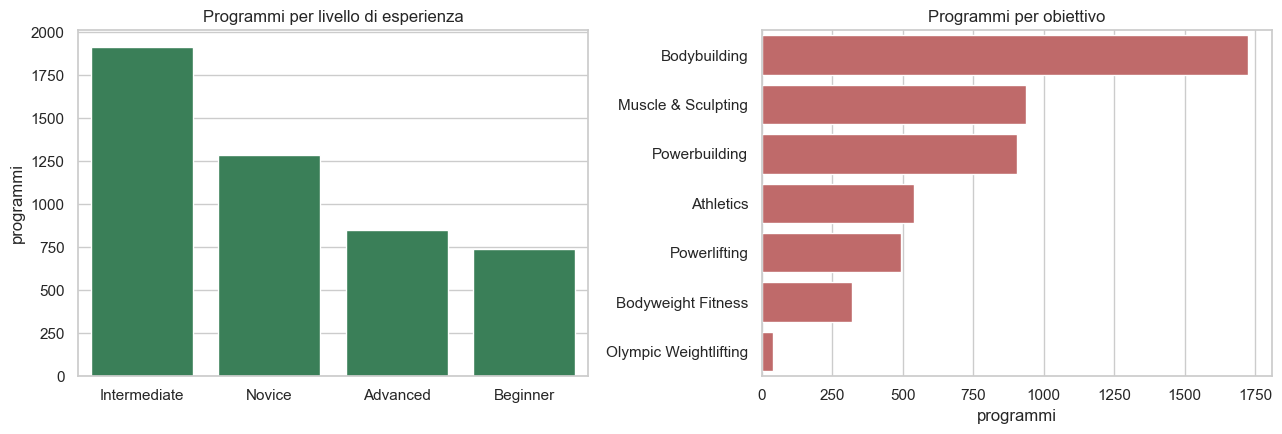

In [9]:
per_level = pd.DataFrame(list(programs.aggregate([
    {"$unwind": "$level"},
    {"$group": {"_id": "$level", "programmi": {"$sum": 1}}},
    {"$sort": {"programmi": -1}},
]))).rename(columns={"_id": "level"})

per_goal = pd.DataFrame(list(programs.aggregate([
    {"$unwind": "$goal"},
    {"$group": {"_id": "$goal", "programmi": {"$sum": 1}}},
    {"$sort": {"programmi": -1}},
]))).rename(columns={"_id": "goal"})

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.barplot(data=per_level, x="level", y="programmi", color="seagreen", ax=axes[0])
axes[0].set_title("Programmi per livello di esperienza")
axes[0].set_xlabel("")
sns.barplot(data=per_goal, y="goal", x="programmi", color="indianred", ax=axes[1])
axes[1].set_title("Programmi per obiettivo")
axes[1].set_ylabel("")
plt.tight_layout(); plt.show()

Sfruttando nuovamente la clausola $unwind è possibile andare a plottare la distribuzione dei programmi di allenamento (notiamo che sono più dei 2500 docuemnti collassati, ma è normale in quanto un piano indica più livelli e più obiettivi). 

Osserviamo che il dataset non è orientato agli estremi, ovvero che Beginner e Advanced hanno molti meno piani rispetto Novice e Intermediate.
Gli obiettivi più presenti invece risultano essere Bodybuilding, Muscle & Sculpting e Powerbuilding. Il che conferma perché gli esercizi più presenti nei vari piani fossero i fondamentali.

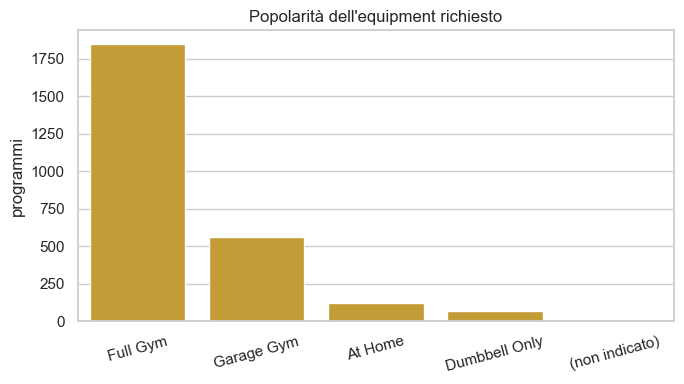

Esercizi per programma — media: 232.9, min: 1, max: 5,040


In [10]:
per_equipment = pd.DataFrame(list(programs.aggregate([
    {"$group": {"_id": {"$ifNull": ["$equipment", "(non indicato)"]},
                "programmi": {"$sum": 1}}},
    {"$sort": {"programmi": -1}},
]))).rename(columns={"_id": "equipment"})

stats_es = list(programs.aggregate([
    {"$project": {"n_esercizi": {"$sum": {"$map": {
        "input": "$weeks", "as": "w",
        "in": {"$sum": {"$map": {"input": "$$w.days", "as": "d",
                                 "in": {"$size": "$$d.exercises"}}}}}}}}},
    {"$group": {"_id": None, "media": {"$avg": "$n_esercizi"},
                "min": {"$min": "$n_esercizi"}, "max": {"$max": "$n_esercizi"}}},
]))[0]

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=per_equipment, x="equipment", y="programmi", color="goldenrod", ax=ax)
ax.set_title("Popolarità dell'equipment richiesto")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=15)
plt.tight_layout(); plt.show()

print(f"Esercizi per programma — media: {stats_es['media']:.1f}, "
      f"min: {stats_es['min']}, max: {stats_es['max']:,}")

In questa query invece ho stampato la distribuzione delle strutture richieste per eseguire i programmi.
Questa query è stata fatta per dimostrare che anche usando una tecnica di embedding, e quindi andando a collassare i documenti, possiamo usare funzioni quali $map e $sum al posto di $unwind per andare lavorare dentro gli array. 
Questo dimostra il potenziale e la versatilità che vi è dietro le aggregation expression di MongoDB.

Inoltre analizzando il plot possiamo vedere come la maggior parte dei piani risultino richiedere una Full Gym o almeno una Garage Gym per essere eseguiti.


In [11]:
facet = list(programs.aggregate([{"$facet": {
    "programmi_totali": [{"$count": "n"}],
    "durata": [{"$group": {"_id": None,
                           "settimane_medie": {"$avg": "$program_length"},
                           "minuti_per_workout": {"$avg": "$time_per_workout"}}}],
    "top_goal": [{"$unwind": "$goal"},
                 {"$group": {"_id": "$goal", "n": {"$sum": 1}}},
                 {"$sort": {"n": -1}}, {"$limit": 3}],
    "per_level": [{"$unwind": "$level"},
                  {"$group": {"_id": "$level", "n": {"$sum": 1}}},
                  {"$sort": {"n": -1}}],
}}]))[0]

print("Programmi totali :", facet["programmi_totali"][0]["n"])
d = facet["durata"][0]
print(f"Durata media     : {d['settimane_medie']:.1f} settimane, "
      f"{d['minuti_per_workout']:.0f} min/workout")
print("Top 3 obiettivi  :", ", ".join(f"{g['_id']} ({g['n']})" for g in facet["top_goal"]))
print("Per livello      :", ", ".join(f"{l['_id']} ({l['n']})" for l in facet["per_level"]))

Programmi totali : 2598
Durata media     : 8.8 settimane, 69 min/workout
Top 3 obiettivi  : Bodybuilding (1723), Muscle & Sculpting (936), Powerbuilding (905)
Per livello      : Intermediate (1914), Novice (1283), Advanced (848), Beginner (737)


Ho voluto approfondire un aspetto molto utile di MongoDB, il $facet.

Questa clausola permette di andare a restituire un unico documento in output basato su tutti i risultati. Tipicamente questa tecnica viene usata in pagine di riepilogo e/o dashboard in quanto permette con una sola scansione nel DB di ottenere N metriche. Questo lo fa andando ad eseguire più sotto pipeline indipendenti. Questo la rende molto simile con la funzione pandas .describe() che in un sol colpo restituisce varie metriche del dataframe.


**Risposta a RQ2**: l'aggregation framework mi ha permesso di fare varie e vaste operazioni sui dati del mio database pur mantenendo alta l'efficienza senza spotare i dati fuori dal database.


## 5. RQ3 — Indici e performance

Quando lavoriamo con database (e soprattutto con grandi quantità di dati) è necessario saper sfruttare gli indici messi a disposizione. 
Così come fatto nel corso di Database e per Neo4j ho deciso di implementare una sezione dedicata anche in questo progetto.

Su mongo DB, se non vi sono indici sui campi dei documenti, quello che avviene è una COLLSCAN, ovvero viene letta tutta la collection e applicato il filtro documento per documento. 

Quello che farò nella prossima cella è quello di lavorare sul database 'workouts' piatto, non collassato, in quanto rappresenta il caso peggiore. 
Andrò a lanciare due query filtrando sul campo 'exercise_name' nella prima query e nella seconda invece applicherò un doppio filtro ('exercise_name'+'equipment').

Dopodiché profilo tutto usando 'explain(executionStats') che (come su Neo4j PROFILE) ci permette di vedere il piano scelto, il numero di documenti esaminati, il tempo d'esecuzione della query etc...

In [12]:
workouts = db["workouts"]
workouts.drop_indexes()        #riparto senza indici secondari

def explain_stats(label, query, projection=None):
    cmd = {"find": "workouts", "filter": query}
    if projection:
        cmd["projection"] = projection
    exp = db.command("explain", cmd, verbosity="executionStats")
    wp = exp["queryPlanner"]["winningPlan"]
    if "queryPlan" in wp:                      
        wp = wp["queryPlan"]
    stages, s = [], wp
    while s:
        stages.append(s.get("stage"))
        s = s.get("inputStage")
    es = exp["executionStats"]
    return {"scenario": label,
            "piano": " → ".join(stages),
            "nReturned": es["nReturned"],
            "docsExamined": es["totalDocsExamined"],
            "keysExamined": es["totalKeysExamined"],
            "tempo (ms)": es["executionTimeMillis"]}

# Esercizio più frequente
EX = top_df.iloc[0]["esercizio"]              
Q_SINGLE   = {"exercise_name": EX}
Q_COMPOUND = {"equipment": "Garage Gym", "exercise_name": EX}
print(f"Query di test: exercise_name = '{EX}'")

baseline = [explain_stats("filtro singolo — senza indice", Q_SINGLE),
            explain_stats("filtro doppio — senza indice", Q_COMPOUND)]
pd.DataFrame(baseline).set_index("scenario")

Query di test: exercise_name = 'Bench Press (Barbell)'


,piano,nReturned,docsExamined,keysExamined,tempo (ms)
scenario,,,,,
filtro singolo — senza indice,COLLSCAN,16508,605033,0,276
filtro doppio — senza indice,COLLSCAN,4116,605033,0,284


Come previsto quello che avviene è che senza alcun indice la scansione COLLSCAN avvenga su tutta la collezione di documenti andando a filtrare poi documento per documento.
Ragionando in termini di dataset molto più grandi, come quelli utilizzati dalle grandi aziende, query di questo tipo non sono accettabili, in quanto con l'aumentare dei dati, aumenta anche il tempo richiesto per performare la query.

Ora creo dunque un indice su 'exercise_name' e un indice composto su 'exercise_name'+'equipment' e ripeto le stesse query profilandole.

In [13]:
workouts.create_index([("exercise_name", ASCENDING)], name="idx_exercise")
workouts.create_index([("equipment", ASCENDING), ("exercise_name", ASCENDING)],
                      name="idx_equip_exercise")
print("Indici presenti:", [i["name"] for i in workouts.list_indexes()])

dopo = [
    explain_stats("filtro singolo — indice singolo", Q_SINGLE),
    explain_stats("filtro doppio — indice composto", Q_COMPOUND),
    explain_stats("filtro doppio — covered query", Q_COMPOUND,
                  {"_id": 0, "equipment": 1, "exercise_name": 1}),
]
pd.DataFrame(baseline + dopo).set_index("scenario")

Indici presenti: ['_id_', 'idx_exercise', 'idx_equip_exercise']


,piano,nReturned,docsExamined,keysExamined,tempo (ms)
scenario,,,,,
filtro singolo — senza indice,COLLSCAN,16508,605033,0,276
filtro doppio — senza indice,COLLSCAN,4116,605033,0,284
filtro singolo — indice singolo,FETCH → IXSCAN,16508,16508,16508,39
filtro doppio — indice composto,FETCH → IXSCAN,4116,4116,4116,6
filtro doppio — covered query,PROJECTION_COVERED → IXSCAN,4116,0,4116,2



1. **`IXSCAN` + `FETCH`**: con l'indice, MongoDB naviga il B-tree fino alle chiavi che soddisfano il filtro (keysExamined = nReturned) e va a prendere solo i documenti che soddisfano la condizione: `docsExamined` crolla da 605.033 a 16.508 (i soli documenti restituiti) e il tempo da ~280 a ~40 ms.
2. **Indice composto**: la query sui due campi utilizza l'indice composto e vediamo riportare i 4116 docuemnti in 6ms.
3. **Covered query**: questo tipo di query è un caso particolare di query dove vengono richiesti solo i campi che sono nell'indice. In questo caso la pipeline eseguita da MongoDB passa da lettura indice -> fetch dei dati (lettura dei documenti) -> ritornare i documenti che rispettano il filtro a lettura indice e ritornare i documenti. Il tempo viene ulteriormente abbattuto in quanto si salta la fase più dispendiosa nell'esecuzione di una query, ovvero leggere effettivamente i documenti.

Nonostante la diminuizione significativa del tempo richiesto per recuperare i dati dal DB, creare indici comporta aggiungere strutture dati (che vanno memorizzate e che quindi occupano spazio solo per la creazione) che devono essere aggiornate. Su collezioni nelle quali vengono eseguite frequenti scritture, potrebbe essere necessario calcolarne i benefici per capire l'effettivo guadagno.

**Risposta a RQ3**: l'impatto è di 2-3 ordini di grandezza sui documenti esaminati.


## 6. RQ4 — Il CAP Theorem, sperimentato sul replica set

Il CAP theorem dice che un sistema distribuito, al fronte di una Partizione di rete (P), deve scegliere tra essere Consistente (C) e Disponibile (A).
MongoDB sceglie la consistenza, ovvero risulta essere un sistema CP. 

In questa sezione dimostro la reazione del sistema MongoDB di fronte a "guasti" sui nodi. 
Su MongoDB possiamo impostare quello che viene chiamato "write concern" (ovvero la policy secondo la quale viene descritta la durabilità di una scrittura) ai seguenti livelli:
- w:1 (scrittura ok dopo il nodo primary)
- w:2 (scrittura ok dopo primary + 1 secondary)
- w:majority (srittura ok dopo che ha scritto sulla maggiorparte dei dati)

É possibile anche impostare la "read preference" (ovvero scegliere da quali nodi leggere) ai seguenti valori:
- primary (leggiamo da nodo primario)
- secondary (leggiamo da nodi secondari)
- nearest (leggiamo dal nodo più vicino nella rete distribuita)
- primaryPreferred (preferiamo leggere dal nodo primario, ma se questo è down allora leggiamo dal secondary)

Per simulare la partizione fermerò il container Docker del primary e osserveremo cosa succederà.


In [14]:
PORT2CONTAINER = {27017: "mongo1", 27018: "mongo2", 27019: "mongo3"}

status = client.admin.command("replSetGetStatus")
primary = next(m for m in status["members"] if m["stateStr"] == "PRIMARY")
primary_container = PORT2CONTAINER[int(primary["name"].split(":")[1])]

print(f"Primary attuale: {primary['name']}  (container '{primary_container}')")
pd.DataFrame([{"membro": m["name"], "stato": m["stateStr"], "health": int(m["health"])}
              for m in status["members"]])

Primary attuale: localhost:27017  (container 'mongo1')


,membro,stato,health
0,localhost:27017,PRIMARY,1
1,localhost:27018,SECONDARY,1
2,localhost:27019,SECONDARY,1


### 6.1 Write concern: quanto costa la durabilità

Il **write concern** regola quando una scrittura è considerata confermata: `w: 1` appena il primary l'ha applicata, `w: "majority"` quando la maggioranza dei nodi l'ha replicata. Misuro il costo di questa garanzia inserendo gli stessi batch con i due livelli:


In [15]:
N_DOC, RUNS = 500, 5
risultati = {}
for etichetta, wc in [("w=1", WriteConcern(w=1)),
                      ('w="majority"', WriteConcern(w="majority"))]:
    coll = db.get_collection("wc_test", write_concern=wc)
    coll.drop()
    tempi = []
    for r in range(RUNS):
        docs = [{"run": r, "i": i} for i in range(N_DOC)]
        t0 = time.perf_counter()
        coll.insert_many(docs)
        tempi.append((time.perf_counter() - t0) * 1000)
    risultati[etichetta] = tempi
db["wc_test"].drop()

pd.DataFrame(risultati).agg(["mean", "min", "max"]).round(1).rename(
    index={"mean": "media (ms)", "min": "min (ms)", "max": "max (ms)"})

,w=1,"w=""majority"""
media (ms),15.6,20.1
min (ms),4.4,10.3
max (ms),55.4,45.0


`w: "majority"` paga un "sovrapprezzo" rispetto a `w: 1`: la conferma deve attendere la replica su almeno un secondary. Su localhost il divario è di pochi millisecondi, ma in un cluster geo-distribuito diventa la latenza di rete tra datacenter.
 
In cambio, `majority` garantisce che la scrittura sopravviva a un failover, in quanto una scrittura con `w: 1` viene annullata se il primary cade prima di replicarla.
Questo rappresenta proprio il trade-off tra C e A, più aggiungiamo garanzie di consistenza, più aumenta la latenza


### 6.2 Read preference: leggere dai secondary


In [16]:
coll_secondary = db.get_collection("workouts", read_preference=ReadPreference.SECONDARY)

cur_p = db.workouts.find({}, {"_id": 1}).limit(1); next(cur_p)
cur_s = coll_secondary.find({}, {"_id": 1}).limit(1); next(cur_s)

print("readPreference=primary   -> lettura servita da", cur_p.address)
print("readPreference=secondary -> lettura servita da", cur_s.address)
print("count su primary  :", db.workouts.count_documents({}))
print("count su secondary:", coll_secondary.count_documents({}))

readPreference=primary   -> lettura servita da ('localhost', 27017)
readPreference=secondary -> lettura servita da ('localhost', 27018)
count su primary  : 605033


count su secondary: 605033


Con `readPreference=secondary` il driver instrada la lettura su un nodo secondario che vediamo avere lo stesso numero di documenti del nodo primario.


### 6.3 Failover: il cluster perde il primary

L'esperimento centrale della RQ4. Uccido il container del primary con **`docker kill`**  e, una volta al secondo, provo a scrivere e a leggere da un secondary, registrando gli esiti su una timeline.

> **Perché `kill` e non `stop`?** Con `docker stop` il mongod riceve SIGTERM e fa uno riavvio graduale: avvisa i secondary, che eleggono il nuovo primary quasi istantaneamente — l'ho verificato, e la finestra di indisponibilità è invisibile. È il meccanismo usato nei riavvii pianificati.
Il teorema CAP però parla di guasti non pianificati per questo usando docker kill mi assicuro che il segnale sia un SIGKILL e questo fa partire un timeout di 10s di default prima di indire l'elezione.

In [17]:
print(f"Uccido il container del primary: {primary_container} ({primary['name']})")
subprocess.run(["docker", "kill", primary_container], check=True, capture_output=True)

fast = MongoClient(MONGO_URI, serverSelectionTimeoutMS=2000)
w_coll = fast[MONGO_DB]["failover_test"]
r_coll = fast[MONGO_DB].get_collection("workouts",
                                       read_preference=ReadPreference.SECONDARY)

timeline, nuovo_primary = [], None
t_start = time.perf_counter()
while time.perf_counter() - t_start < 120:
    t = time.perf_counter() - t_start
    try:
        w_coll.insert_one({"t": t})
        esito_w = "OK"
        nuovo_primary = fast.primary
    except Exception as e:
        esito_w = f"BLOCCATA ({type(e).__name__})"
    try:
        cur = r_coll.find({}, {"_id": 1}).limit(1); next(cur)
        esito_r = f"OK (porta {cur.address[1]})"
    except Exception as e:
        esito_r = f"FALLITA ({type(e).__name__})"
    timeline.append({"t (s)": round(t, 1), "scrittura": esito_w,
                     "lettura da secondary": esito_r})
    if esito_w == "OK":
        break
    time.sleep(1)

print(f"Nuovo primary eletto: {nuovo_primary}")
pd.DataFrame(timeline)

Uccido il container del primary: mongo1 (localhost:27017)


Nuovo primary eletto: ('localhost', 27018)


,t (s),scrittura,lettura da secondary
0,0.0,BLOCCATA (ServerSelectionTimeoutError),OK (porta 27018)
1,3.0,BLOCCATA (ServerSelectionTimeoutError),OK (porta 27019)
2,6.1,BLOCCATA (ServerSelectionTimeoutError),OK (porta 27018)
3,9.1,OK,OK (porta 27019)


La timeline mostra il comportamento CP di MongoDB in diretta:

- **Le scritture si bloccano** per l'intera durata dell'elezione,~10 secondi, il driver non trova un primary (perché non esiste al momento). Il sistema sacrifica la disponibilità in scrittura pur di non rischiare due primary concorrenti.
- **Le letture dai secondary continuano**: non cambia però la disponibilità in lettura. 
- I due nodi superstiti formano ancora la maggioranza (2 su 3), quindi possono eleggere un nuovo primary e il servizio riprende da solo. Se avessi fermato due nodi, il nodo superstite sarebbe rimasto secondary per sempre: nessuna maggioranza, nessun primary, niente scritture.


In [18]:
print(f"Riavvio il container {primary_container}")
subprocess.run(["docker", "start", primary_container], check=True, capture_output=True)

for _ in range(30):
    time.sleep(2)
    stati = {m["name"]: m["stateStr"]
             for m in client.admin.command("replSetGetStatus")["members"]}
    if all(s in ("PRIMARY", "SECONDARY") for s in stati.values()):
        break

fast[MONGO_DB]["failover_test"].drop()
fast.close()
pd.DataFrame([{"membro": k, "stato": v} for k, v in stati.items()])

Riavvio il container mongo1


,membro,stato
0,localhost:27017,SECONDARY
1,localhost:27018,PRIMARY
2,localhost:27019,SECONDARY


Il vecchio primary, riavviato, rientra nel replica set come SECONDARY: si risincronizza dal nuovo primary e recupera le scritture perse durante la sua assenza. Nessun intervento manuale.

**Risposta a RQ4 — la mappa completa su CAP:**

| Evento osservato | Lettura CAP |
|---|---|
| Scritture bloccate durante l'elezione (~10s) | sotto partizione MongoDB sacrifica **A** per **C** → sistema **CP** |
| `w:"majority"` più lento di `w:1` | il *grado* di C si paga in latenza, scrittura per scrittura |
| Serve la maggioranza per eleggere il primary | protezione dallo split-brain: mai due "verità" divergenti |

## 7. Conclusioni

In questo approfondimento ho esplorato MongoDB sui quattro assi delle research question, con esperimenti riproducibili su un replica set Docker a 3 nodi:

- **RQ1 — Modellazione.** Il dataset piatto (605k righe con metadati duplicati) è stato rimodellato in 2.598 documenti annidati programma → settimane → giorni → esercizi con una sola pipeline di aggregazione (`$group` ×3 + `$out`). Risultato: dati logici da 414 a 54 MB (−87%) e l'intero programma recuperabile con una singola lettura atomica (~1,2 ms contro ~165) — l'embedding vince quando l'unità di accesso coincide con il documento, il referencing resta preferibile per sotto-oggetti condivisi o array a crescita illimitata (limite BSON 16 MB).
- **RQ2 — Aggregation framework.** Tutta l'analisi descrittiva (top esercizi, distribuzioni per livello/obiettivo/equipment, statistiche multi-metrica con `$facet`) è stata eseguita dentro il database: `$unwind` riapre la gerarchia quando serve la granularità fine, `$map`/`$size` navigano gli array senza esploderli.
- **RQ3 — Indici.** Con `explain("executionStats")` ho misurato il passaggio da `COLLSCAN` (605k documenti esaminati) a `IXSCAN` (solo i documenti restituiti) fino alla covered query (`docsExamined = 0`): 2-3 ordini di grandezza, al costo di spazio e overhead in scrittura.
- **RQ4 — CAP.** Il failover dal vivo ha mostrato il carattere CP di MongoDB: alla caduta del primary le scritture si bloccano per i ~10 secondi dell'elezione (consistenza pagata in disponibilità), le letture dai secondary proseguono in consistenza eventuale, e write/read concern permettono di regolare il trade-off C/latenza per singola operazione.

In [19]:
client.close()
print("Connessione al replica set chiusa.")

Connessione al replica set chiusa.
